<a href="https://colab.research.google.com/github/Abrewst/ML-repo/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import files
upload = files.upload()

Saving Housing.csv to Housing (1).csv


In [17]:
import io
import pandas as pd

df = pd.read_csv('Housing.csv')


--- Training nonlinear model (lr=0.1) ---
Epoch     0 | Loss=  675.7944 | Params=[0.013048443011939526, 0.8413195610046387, -0.027333421632647514]
Epoch   500 | Loss=  656.1529 | Params=[0.3190155029296875, -1.0025326013565063, -0.9311535954475403]
Epoch  1000 | Loss=  655.6646 | Params=[0.3598378598690033, -1.222540259361267, -1.1855108737945557]
Epoch  1500 | Loss=  655.5782 | Params=[0.3615286350250244, -1.2074085474014282, -1.3437318801879883]
Epoch  2000 | Loss=  655.5104 | Params=[0.35753333568573, -1.158490777015686, -1.4860261678695679]
Epoch  2500 | Loss=  655.4429 | Params=[0.35276585817337036, -1.1053192615509033, -1.6241878271102905]
Epoch  3000 | Loss=  655.3705 | Params=[0.3479442894458771, -1.0522152185440063, -1.7599745988845825]
Epoch  3500 | Loss=  655.3123 | Params=[0.34318462014198303, -0.9998055100440979, -1.8936716318130493]
Epoch  4000 | Loss=  655.2514 | Params=[0.3384912312030792, -0.948166012763977, -2.0253489017486572]
Epoch  4500 | Loss=  655.2056 | Params=

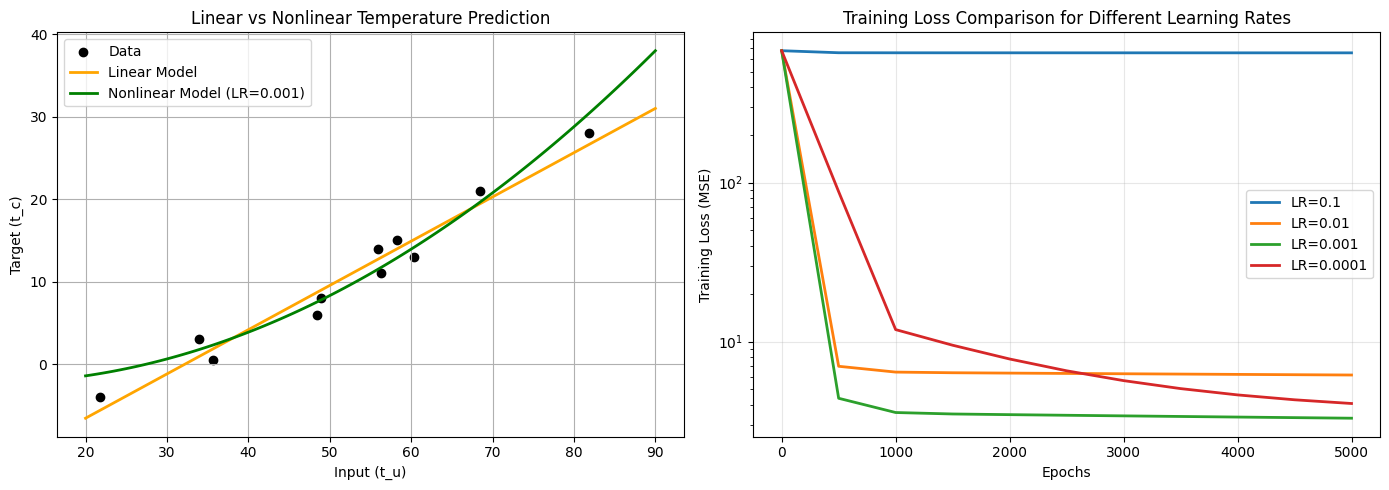


=== Final Comparison ===
Linear model loss: 2.927647
Best nonlinear model loss: 3.297914
Linear model is BETTER by 12.65%


In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt


t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

t_un = 0.1 * t_u

# -----------------------------
# 1.a Nonlinear model
# -----------------------------
def model(t_u, w2, w1, b):
    return w2 * t_u ** 2 + w1 * t_u + b

# Loss function (MSE)
def loss_fn(t_p, t_c):
    return ((t_p - t_c) ** 2).mean()

# -----------------------------
# Training function (NaN-safe)
# -----------------------------
def train_model(lr, epochs=5000):
    params = torch.tensor([1.0, 1.0, 0.0], requires_grad=True)  # [w2, w1, b]
    optimizer = optim.SGD([params], lr=lr)
    losses = []

    print(f"\n--- Training nonlinear model (lr={lr}) ---")
    for epoch in range(epochs + 1):
        t_p = model(t_un, *params)
        loss = loss_fn(t_p, t_c)

        # Check for NaN / Inf
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"⚠️ NaN/Inf detected at epoch {epoch}. Stopping early.")
            break

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_([params], max_norm=10.0)

        optimizer.step()

        # Early stop if exploding loss
        if loss.item() > 1e6:
            print(f"⚠️ Loss exploded at epoch {epoch}. Stopping early.")
            break

        if epoch % 500 == 0:
            losses.append(loss.item())
            print(f"Epoch {epoch:5d} | Loss={loss.item():10.4f} | Params={params.data.tolist()}")

    return params.detach(), losses

# -----------------------------
# 1.b Train with different learning rates
# -----------------------------
learning_rates = [0.1, 0.01, 0.001, 0.0001]
trained_models = {}

for lr in learning_rates:
    params, losses = train_model(lr)
    trained_models[lr] = (params, losses)

# -----------------------------
# 1.c Linear baseline model
# -----------------------------
def linear_model(t_u, w, b):
    return w * t_u + b

def train_linear(lr=1e-2, epochs=5000):
    params = torch.tensor([1.0, 0.0], requires_grad=True)
    optimizer = optim.SGD([params], lr=lr)
    for epoch in range(epochs):
        t_p = linear_model(t_un, *params)
        loss = loss_fn(t_p, t_c)
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"⚠️ NaN/Inf detected in linear model at epoch {epoch}")
            break
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return params.detach(), loss.item()

linear_params, linear_loss = train_linear()

# -----------------------------
# Find best nonlinear model
# -----------------------------
valid_models = {lr: m for lr, m in trained_models.items() if len(m[1]) > 0}
best_lr = min(valid_models, key=lambda x: valid_models[x][1][-1])
best_params, best_losses = valid_models[best_lr]
best_nonlinear_loss = best_losses[-1]

print(f"\n=== Results Summary ===")
print(f"Best nonlinear model: LR={best_lr}")
print(f"Parameters: {best_params}")
print(f"Final nonlinear loss: {best_nonlinear_loss:.4f}")
print(f"Linear model loss:    {linear_loss:.4f}")

# -----------------------------
# Visualization 1: Model Fit
# -----------------------------
t_range = torch.linspace(20, 90, 100)
t_range_n = 0.1 * t_range

linear_pred = linear_model(t_range_n, *linear_params)
nonlinear_pred = model(t_range_n, *best_params)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.scatter(t_u, t_c, label='Data', color='black')
plt.plot(t_range, linear_pred, label='Linear Model', color='orange', linewidth=2)
plt.plot(t_range, nonlinear_pred, label=f'Nonlinear Model (LR={best_lr})', color='green', linewidth=2)
plt.xlabel("Input (t_u)")
plt.ylabel("Target (t_c)")
plt.title("Linear vs Nonlinear Temperature Prediction")
plt.legend()
plt.grid(True)

# -----------------------------
# Visualization 2: Training Loss Comparison
# -----------------------------
plt.subplot(1,2,2)
for lr, (params, losses) in trained_models.items():
    if len(losses) > 0:
        epochs_plot = [i*500 for i in range(len(losses))]
        plt.plot(epochs_plot, losses, label=f'LR={lr}', linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Comparison for Different Learning Rates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

# -----------------------------
# Final Comparison
# -----------------------------
improvement = ((linear_loss - best_nonlinear_loss) / linear_loss) * 100
print(f"\n=== Final Comparison ===")
print(f"Linear model loss: {linear_loss:.6f}")
print(f"Best nonlinear model loss: {best_nonlinear_loss:.6f}")
if best_nonlinear_loss < linear_loss:
    print(f"Nonlinear model is BETTER by {improvement:.2f}%")
else:
    print(f"Linear model is BETTER by {-improvement:.2f}%")


Dataset shape: (545, 13)

Dataset head:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Training with learning rate: 0.1
Epoch 500: Train Loss=0.4

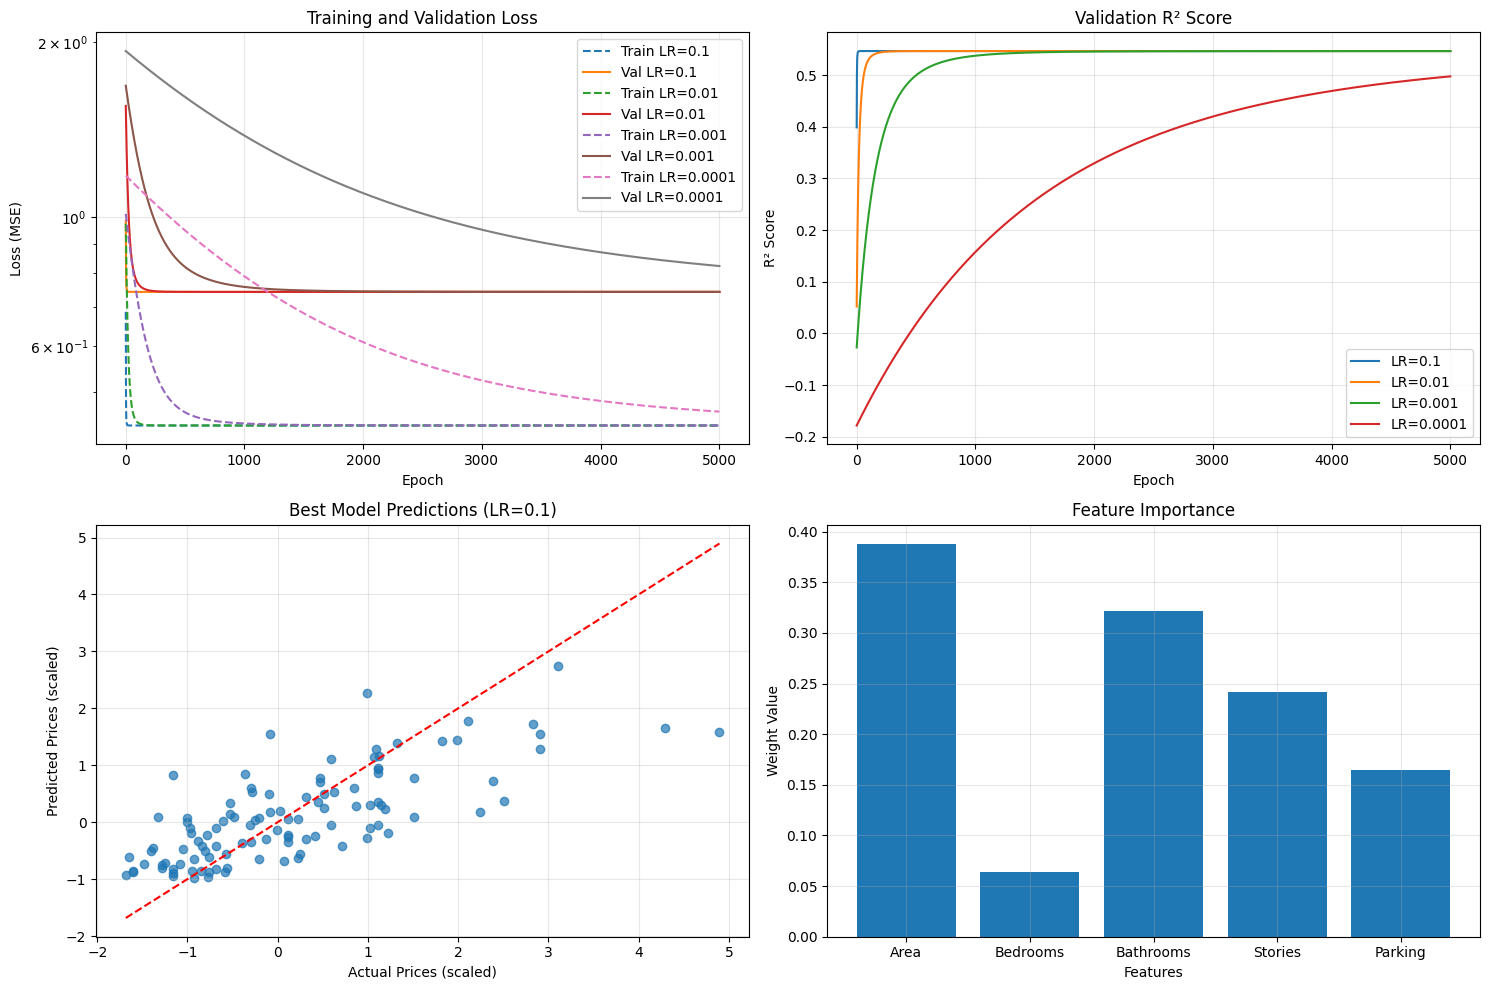


FINAL LINEAR REGRESSION MODEL (Scaled)
Price = 0.387286 × Area
       + 0.064337 × Bedrooms
       + 0.321994 × Bathrooms
       + 0.241666 × Stories
       + 0.164212 × Parking
       + 0.000000


In [7]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("Housing.csv")
print("Dataset shape:", df.shape)
print("\nDataset head:")
print(df.head())

# -----------------------------
# Preprocessing
# -----------------------------
def preprocess_data(df, test_size=0.2):
    X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']].values
    y = df['price'].values

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=42)

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

    return X_train_scaled, X_val_scaled, y_train_scaled, y_val_scaled, scaler_X, scaler_y

X_train, X_val, y_train, y_val, scaler_X, scaler_y = preprocess_data(df)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# -----------------------------
# Linear Model and Metrics
# -----------------------------
def linear_model(X, weights, bias):
    return torch.matmul(X, weights) + bias

def loss_fn(predictions, targets):
    return ((predictions - targets) ** 2).mean()

def r2_score(predictions, targets):
    ss_res = torch.sum((targets - predictions) ** 2)
    ss_tot = torch.sum((targets - torch.mean(targets)) ** 2)
    return 1 - ss_res / ss_tot

# -----------------------------
# Training Loop with Validation
# -----------------------------
def training_loop_with_validation(n_epochs, learning_rate, params, X_train, y_train, X_val, y_val):
    weights, bias = params
    train_losses = []
    val_losses = []
    val_r2_scores = []

    for epoch in range(1, n_epochs + 1):
        # Zero gradients
        if weights.grad is not None:
            weights.grad.zero_()
        if bias.grad is not None:
            bias.grad.zero_()

        # Forward pass
        train_pred = linear_model(X_train, weights, bias)
        train_loss = loss_fn(train_pred, y_train)

        # Backward pass
        train_loss.backward()

        # Update parameters
        with torch.no_grad():
            weights -= learning_rate * weights.grad
            bias -= learning_rate * bias.grad

        # Validation
        with torch.no_grad():
            val_pred = linear_model(X_val, weights, bias)
            val_loss = loss_fn(val_pred, y_val)
            val_r2 = r2_score(val_pred, y_val)

        # Store metrics
        train_losses.append((epoch, float(train_loss)))
        val_losses.append((epoch, float(val_loss)))
        val_r2_scores.append((epoch, float(val_r2)))

        # Print progress every 500 epochs
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Train Loss={float(train_loss):.6f}, Val Loss={float(val_loss):.6f}, Val R²={float(val_r2):.4f}")

    return (weights, bias), train_losses, val_losses, val_r2_scores

# -----------------------------
# Train with different learning rates
# -----------------------------
learning_rates = [0.1, 0.01, 0.001, 0.0001]
all_results = {}

for lr in learning_rates:
    print(f"\n{'='*50}\nTraining with learning rate: {lr}\n{'='*50}")

    # Initialize leaf tensors correctly
    weights = torch.randn(5, requires_grad=True)
    weights.data *= 0.1  # in-place scaling keeps it a leaf tensor
    bias = torch.tensor(0.0, requires_grad=True)

    final_params, train_losses, val_losses, val_r2_scores = training_loop_with_validation(
        n_epochs=5000,
        learning_rate=lr,
        params=(weights, bias),
        X_train=X_train_tensor,
        y_train=y_train_tensor,
        X_val=X_val_tensor,
        y_val=y_val_tensor
    )

    all_results[lr] = {
        'final_params': final_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_r2_scores': val_r2_scores,
        'final_val_loss': val_losses[-1][1],
        'final_r2': val_r2_scores[-1][1]
    }

# -----------------------------
# Select Best Model
# -----------------------------
best_lr = max(all_results.keys(), key=lambda lr: all_results[lr]['final_r2'])
best_result = all_results[best_lr]
best_weights, best_bias = best_result['final_params']

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
for lr in learning_rates:
    result = all_results[lr]
    print(f"LR {lr:.4f}: Val Loss = {result['final_val_loss']:.6f}, R² = {result['final_r2']:.4f}")
print(f"\nBEST MODEL: Learning Rate = {best_lr}")
print(f"Final Validation R²: {best_result['final_r2']:.4f}")
print(f"Final Validation Loss: {best_result['final_val_loss']:.6f}")

# -----------------------------
# Print Individual Weights
# -----------------------------
feature_names = ['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking']
weights_values = best_weights.detach().numpy()

print("\nBest Model Parameters:")
for name, w in zip(feature_names, weights_values):
    print(f"  W ({name.lower()}): {w:.6f}")
print(f"  Bias: {best_bias.item():.6f}")

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(15, 10))

# Training and validation loss
plt.subplot(2, 2, 1)
for lr in learning_rates:
    result = all_results[lr]
    epochs = [x[0] for x in result['train_losses']]
    train_vals = [x[1] for x in result['train_losses']]
    val_vals = [x[1] for x in result['val_losses']]
    plt.plot(epochs, train_vals, '--', label=f'Train LR={lr}')
    plt.plot(epochs, val_vals, '-', label=f'Val LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Validation R²
plt.subplot(2, 2, 2)
for lr in learning_rates:
    result = all_results[lr]
    epochs = [x[0] for x in result['val_r2_scores']]
    r2_vals = [x[1] for x in result['val_r2_scores']]
    plt.plot(epochs, r2_vals, '-', label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.title('Validation R² Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Predictions vs Actual
plt.subplot(2, 2, 3)
with torch.no_grad():
    best_pred = linear_model(X_val_tensor, best_weights, best_bias)
plt.scatter(y_val_tensor.numpy(), best_pred.numpy(), alpha=0.7)
plt.plot([y_val_tensor.min(), y_val_tensor.max()],
         [y_val_tensor.min(), y_val_tensor.max()], 'r--')
plt.xlabel('Actual Prices (scaled)')
plt.ylabel('Predicted Prices (scaled)')
plt.title(f'Best Model Predictions (LR={best_lr})')
plt.grid(True, alpha=0.3)

# Feature importance
plt.subplot(2, 2, 4)
plt.bar(feature_names, weights_values)
plt.xlabel('Features')
plt.ylabel('Weight Value')
plt.title('Feature Importance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Final Model Equation
# -----------------------------
print("\n" + "="*60)
print("FINAL LINEAR REGRESSION MODEL (Scaled)")
print("="*60)
print(f"Price = {best_weights[0].item():.6f} × Area")
print(f"       + {best_weights[1].item():.6f} × Bedrooms")
print(f"       + {best_weights[2].item():.6f} × Bathrooms")
print(f"       + {best_weights[3].item():.6f} × Stories")
print(f"       + {best_weights[4].item():.6f} × Parking")
print(f"       + {best_bias.item():.6f}")



=== Training Model 3.a: One Hidden Layer (8 nodes) ===
Epoch  20 | Train Loss=0.421154 | Val Loss=0.621255 | Val R²=0.5708
Epoch  40 | Train Loss=0.374287 | Val Loss=0.656150 | Val R²=0.5467
Epoch  60 | Train Loss=0.356582 | Val Loss=0.629314 | Val R²=0.5652
Epoch  80 | Train Loss=0.345831 | Val Loss=0.621331 | Val R²=0.5707
Epoch 100 | Train Loss=0.337245 | Val Loss=0.622845 | Val R²=0.5697
Epoch 120 | Train Loss=0.330086 | Val Loss=0.620696 | Val R²=0.5712
Epoch 140 | Train Loss=0.325246 | Val Loss=0.626377 | Val R²=0.5672
Epoch 160 | Train Loss=0.321933 | Val Loss=0.626874 | Val R²=0.5669
Epoch 180 | Train Loss=0.318951 | Val Loss=0.625596 | Val R²=0.5678
Epoch 200 | Train Loss=0.316577 | Val Loss=0.620755 | Val R²=0.5711

Training Time: 0.34 seconds
Final Validation R²: 0.5711
Final Validation Loss: 0.620755

=== Training Model 3.b: Three Hidden Layers (8–8–8) ===
Epoch  20 | Train Loss=0.596545 | Val Loss=1.016041 | Val R²=0.2980
Epoch  40 | Train Loss=0.418322 | Val Loss=0.75493

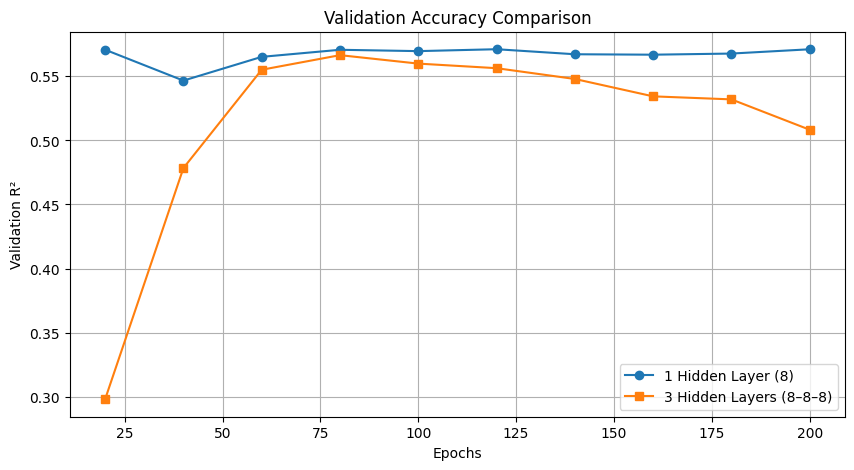


=== Summary ===
Model 3.a (1 hidden layer): Time=0.34s | Val R²=0.5711 | Loss=0.620755
Model 3.b (3 hidden layers): Time=0.53s | Val R²=0.5083 | Loss=0.711638


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt


df = pd.read_csv("Housing.csv")

# ===========================================================
# Preprocess (same as Problem 2)
# ===========================================================
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
target = 'price'

X = df[features].values
y = df[target].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# ===========================================================
# Utility functions
# ===========================================================
def r2_score(pred, target):
    ss_res = torch.sum((target - pred) ** 2)
    ss_tot = torch.sum((target - torch.mean(target)) ** 2)
    return 1 - ss_res / ss_tot

def train_network(model, optimizer, criterion, n_epochs=200):
    start = time.time()
    train_losses, val_losses, val_r2_scores = [], [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_tensor)
        loss = criterion(pred, y_train_tensor)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor)
            val_r2 = r2_score(val_pred, y_val_tensor)

        if epoch % 20 == 0:
            train_losses.append(loss.item())
            val_losses.append(val_loss.item())
            val_r2_scores.append(val_r2.item())
            print(f"Epoch {epoch:3d} | Train Loss={loss.item():.6f} | Val Loss={val_loss.item():.6f} | Val R²={val_r2.item():.4f}")

    total_time = time.time() - start
    return train_losses, val_losses, val_r2_scores, total_time

# ===========================================================
# 3.a — One Hidden Layer (8 nodes)
# ===========================================================
class NN_OneHidden(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x)

print("\n=== Training Model 3.a: One Hidden Layer (8 nodes) ===")
model_3a = NN_OneHidden(input_dim=X_train_tensor.shape[1])
optimizer_3a = optim.Adam(model_3a.parameters(), lr=0.01)
criterion = nn.MSELoss()

train_losses_3a, val_losses_3a, val_r2_3a, time_3a = train_network(model_3a, optimizer_3a, criterion)

print(f"\nTraining Time: {time_3a:.2f} seconds")
print(f"Final Validation R²: {val_r2_3a[-1]:.4f}")
print(f"Final Validation Loss: {val_losses_3a[-1]:.6f}")

# ===========================================================
# 3.b — Three Hidden Layers (8–8–8)
# ===========================================================
class NN_ThreeHidden(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x)

print("\n=== Training Model 3.b: Three Hidden Layers (8–8–8) ===")
model_3b = NN_ThreeHidden(input_dim=X_train_tensor.shape[1])
optimizer_3b = optim.Adam(model_3b.parameters(), lr=0.01)

train_losses_3b, val_losses_3b, val_r2_3b, time_3b = train_network(model_3b, optimizer_3b, criterion)

print(f"\nTraining Time: {time_3b:.2f} seconds")
print(f"Final Validation R²: {val_r2_3b[-1]:.4f}")
print(f"Final Validation Loss: {val_losses_3b[-1]:.6f}")

# ===========================================================
# Comparison and Visualization
# ===========================================================
plt.figure(figsize=(10,5))
plt.plot(range(20, 201, 20), val_r2_3a, 'o-', label='1 Hidden Layer (8)')
plt.plot(range(20, 201, 20), val_r2_3b, 's-', label='3 Hidden Layers (8–8–8)')
plt.xlabel('Epochs')
plt.ylabel('Validation R²')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Summary ===")
print(f"Model 3.a (1 hidden layer): Time={time_3a:.2f}s | Val R²={val_r2_3a[-1]:.4f} | Loss={val_losses_3a[-1]:.6f}")
print(f"Model 3.b (3 hidden layers): Time={time_3b:.2f}s | Val R²={val_r2_3b[-1]:.4f} | Loss={val_losses_3b[-1]:.6f}")


Dataset shape: (545, 13)

Dataset description:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  

Train samples: 436, Val samples: 109

3.a: ONE HIDDEN LAYER (8 nodes)
HousingNet1Layer(
  (layer1): Linear(in_feat

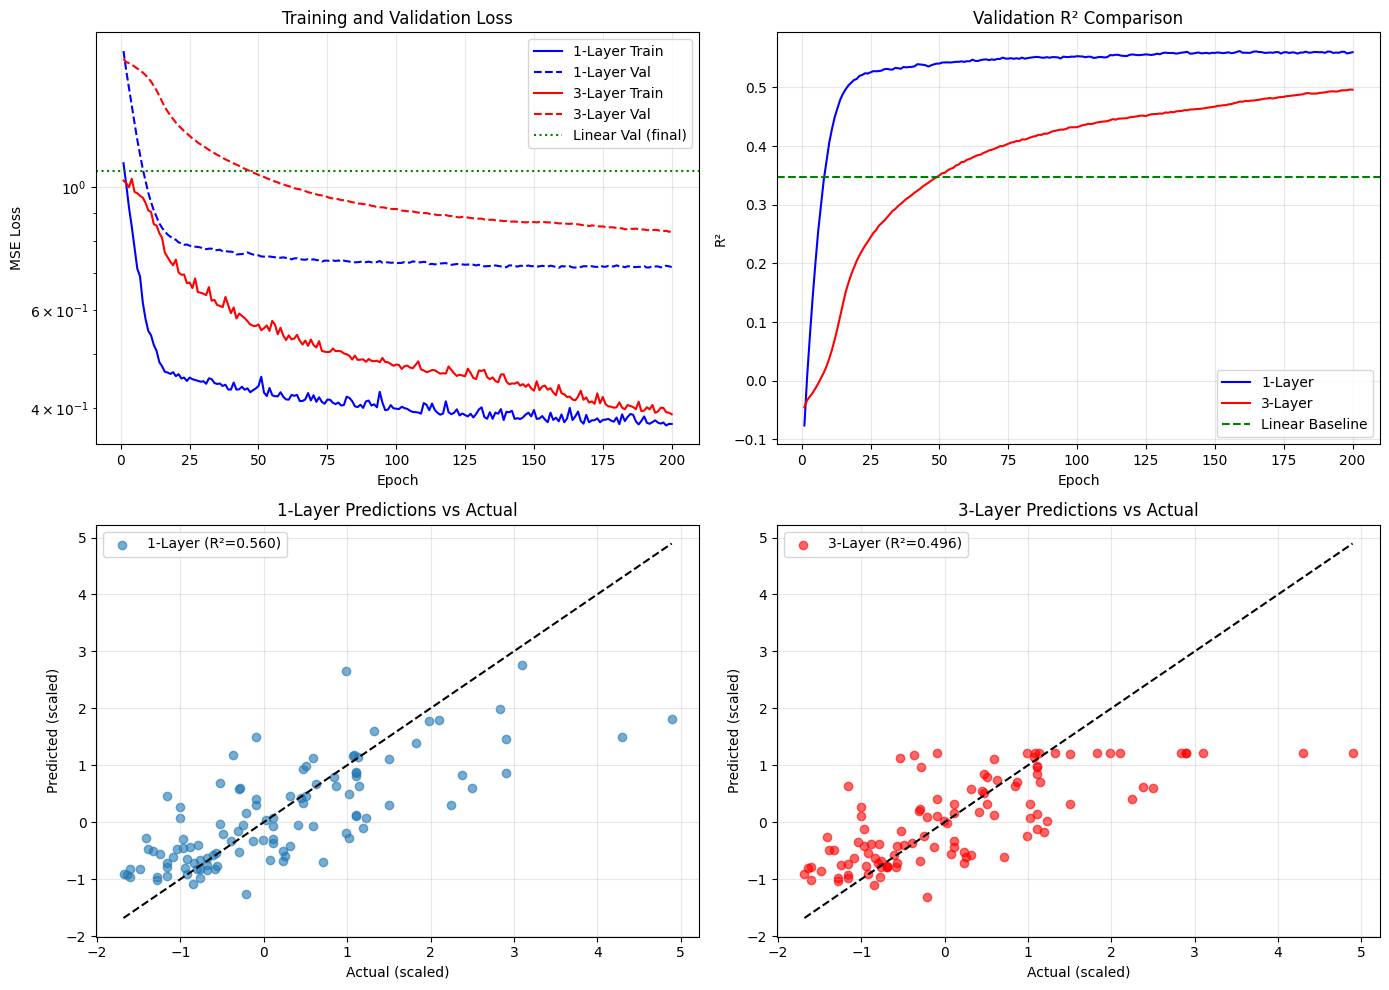

In [19]:


import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader, TensorDataset

# ===========================================================
# Reproducibility
# ===========================================================
torch.manual_seed(42)
np.random.seed(42)

# ===========================================================
# Load real CSV data
# ===========================================================
df = pd.read_csv("Housing.csv")


print("Dataset shape:", df.shape)
print("\nDataset description:")
print(df.describe())

# ===========================================================
# Preprocessing
# ===========================================================
def preprocess_data(df, test_size=0.2):
    X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']].values
    y = df['price'].values.reshape(-1, 1)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=42)

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)

    return (X_train_scaled, X_val_scaled, y_train_scaled, y_val_scaled, scaler_X, scaler_y)

X_train, X_val, y_train, y_val, scaler_X, scaler_y = preprocess_data(df)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nTrain samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# ===========================================================
# 3.a One Hidden Layer Network
# ===========================================================
class HousingNet1Layer(nn.Module):
    def __init__(self, input_size=5, hidden_size=8, output_size=1):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.output(self.relu(self.layer1(x)))

# ===========================================================
# 3.b Three Hidden Layer Network
# ===========================================================
class HousingNet3Layers(nn.Module):
    def __init__(self, input_size=5, hidden1=8, hidden2=6, hidden3=4, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, hidden3)
        self.fc4 = nn.Linear(hidden3, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)

# ===========================================================
# Training helper
# ===========================================================
def train_model(model, train_loader, val_loader, epochs=200, lr=0.001, name="Model"):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, val_r2_scores = [], [], []
    start_time = time.time()

    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        avg_train_loss = epoch_train_loss / len(train_loader)

        model.eval()
        epoch_val_loss = 0
        preds, targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                epoch_val_loss += loss.item()
                preds.extend(pred.numpy())
                targets.extend(yb.numpy())
        avg_val_loss = epoch_val_loss / len(val_loader)
        preds, targets = np.array(preds), np.array(targets)
        ss_res = np.sum((targets - preds)**2)
        ss_tot = np.sum((targets - np.mean(targets))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_r2_scores.append(r2)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] | "
                  f"Train Loss={avg_train_loss:.6f} | Val Loss={avg_val_loss:.6f} | Val R²={r2:.4f}")

    total_time = time.time() - start_time
    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_r2_scores": val_r2_scores,
        "training_time": total_time,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_r2": val_r2_scores[-1],
    }

# ===========================================================
# Count parameters
# ===========================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ===========================================================
# Train 3.a
# ===========================================================
model_1 = HousingNet1Layer()
print("\n3.a: ONE HIDDEN LAYER (8 nodes)")
print(model_1)
print(f"Parameters: {count_parameters(model_1):,}")
results_1 = train_model(model_1, train_loader, val_loader, 200, 0.001, "1-Layer NN")

# ===========================================================
# Train 3.b
# ===========================================================
model_3 = HousingNet3Layers()
print("\n3.b: THREE HIDDEN LAYERS (8-6-4)")
print(model_3)
print(f"Parameters: {count_parameters(model_3):,}")
results_3 = train_model(model_3, train_loader, val_loader, 200, 0.001, "3-Layer NN")

# ===========================================================
# Linear Regression Baseline
# ===========================================================
def train_linear_baseline(X_train, y_train, X_val, y_val, epochs=200, lr=0.001):
    weights = (torch.randn(X_train.shape[1], 1) * 0.1).clone().detach().requires_grad_(True)
    bias = torch.tensor(0.0, requires_grad=True)
    optimizer = optim.SGD([weights, bias], lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses, val_r2 = [], [], []

    for epoch in range(epochs):
        optimizer.zero_grad()
        pred_train = X_train @ weights + bias
        loss_train = criterion(pred_train, y_train)
        loss_train.backward()
        optimizer.step()

        with torch.no_grad():
            pred_val = X_val @ weights + bias
            loss_val = criterion(pred_val, y_val)
            ss_res = torch.sum((y_val - pred_val)**2)
            ss_tot = torch.sum((y_val - torch.mean(y_val))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0

        train_losses.append(loss_train.item())
        val_losses.append(loss_val.item())
        val_r2.append(r2.item())
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss={loss_train.item():.6f} | "
                  f"Val Loss={loss_val.item():.6f} | Val R²={r2:.4f}")

    return {"final_train_loss": train_losses[-1],
            "final_val_loss": val_losses[-1],
            "final_r2": val_r2[-1]}

print("\nLinear Regression Baseline:")
linear_results = train_linear_baseline(X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor)

# ===========================================================
# Results Summary
# ===========================================================
print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)
print(f"{'Model':<30}{'Params':<12}{'Time(s)':<12}{'TrainLoss':<14}{'ValLoss':<14}{'ValR²':<10}")
print("-"*80)
print(f"{'Linear Regression':<30}{6:<12}{'N/A':<12}{linear_results['final_train_loss']:<14.6f}"
      f"{linear_results['final_val_loss']:<14.6f}{linear_results['final_r2']:<10.4f}")
print(f"{'1-Layer NN (8)':<30}{count_parameters(model_1):<12}"
      f"{results_1['training_time']:<12.2f}{results_1['final_train_loss']:<14.6f}"
      f"{results_1['final_val_loss']:<14.6f}{results_1['final_r2']:<10.4f}")
print(f"{'3-Layer NN (8-6-4)':<30}{count_parameters(model_3):<12}"
      f"{results_3['training_time']:<12.2f}{results_3['final_train_loss']:<14.6f}"
      f"{results_3['final_val_loss']:<14.6f}{results_3['final_r2']:<10.4f}")

# ===========================================================
# Visualization
# ===========================================================
plt.figure(figsize=(14,10))
epochs_range = range(1,201)
# Loss curves
plt.subplot(2,2,1)
plt.plot(epochs_range, results_1['train_losses'], 'b-', label='1-Layer Train')
plt.plot(epochs_range, results_1['val_losses'], 'b--', label='1-Layer Val')
plt.plot(epochs_range, results_3['train_losses'], 'r-', label='3-Layer Train')
plt.plot(epochs_range, results_3['val_losses'], 'r--', label='3-Layer Val')
plt.axhline(linear_results['final_val_loss'], color='g', linestyle=':', label='Linear Val (final)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss'); plt.legend(); plt.yscale('log'); plt.grid(True, alpha=0.3)

# R² curves
plt.subplot(2,2,2)
plt.plot(epochs_range, results_1['val_r2_scores'], 'b-', label='1-Layer')
plt.plot(epochs_range, results_3['val_r2_scores'], 'r-', label='3-Layer')
plt.axhline(linear_results['final_r2'], color='g', linestyle='--', label='Linear Baseline')
plt.xlabel('Epoch'); plt.ylabel('R²'); plt.title('Validation R² Comparison')
plt.legend(); plt.grid(True, alpha=0.3)

# Predictions scatter 1-layer
plt.subplot(2,2,3)
model_1.eval()
with torch.no_grad(): preds1 = model_1(X_val_tensor).numpy()
plt.scatter(y_val_tensor.numpy(), preds1, alpha=0.6, label=f'1-Layer (R²={results_1["final_r2"]:.3f})')
plt.plot([y_val_tensor.min(), y_val_tensor.max()], [y_val_tensor.min(), y_val_tensor.max()], 'k--')
plt.xlabel('Actual (scaled)'); plt.ylabel('Predicted (scaled)')
plt.title('1-Layer Predictions vs Actual'); plt.legend(); plt.grid(True, alpha=0.3)

# Predictions scatter 3-layer
plt.subplot(2,2,4)
model_3.eval()
with torch.no_grad(): preds3 = model_3(X_val_tensor).numpy()
plt.scatter(y_val_tensor.numpy(), preds3, alpha=0.6, color='r', label=f'3-Layer (R²={results_3["final_r2"]:.3f})')
plt.plot([y_val_tensor.min(), y_val_tensor.max()], [y_val_tensor.min(), y_val_tensor.max()], 'k--')
plt.xlabel('Actual (scaled)'); plt.ylabel('Predicted (scaled)')
plt.title('3-Layer Predictions vs Actual'); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
